In [23]:
import pandas as pd
from src.preprocessing import preprocess_text

# Load Phase 1 dataset
df = pd.read_csv("data/processed/phase1_dataset.csv")
print(df.shape)
df.head()

(41940, 2)


,text,label
0,كثيرا ما ارتبطت المصادر التاريخية في الأندلس خ...,0
1,يعد العامل الثقافي احد ابرز الاسباب التي يعزى ...,0
2,شكلت تلك الجهود والمساعي الرائدة التي قام بها ...,0
3,يقوم المقال على اشكالية الضرائب الغير شرعية في...,0
4,تتفق المصادر التاريخية المتوفرة حول موضوع تطور...,0


In [24]:
arabic_stopwords = set("""
في على من إلى الى عن أن إن كان تكن تكون يكون تكونون هذا هذه ذلك تلك لكن أو ام ثم حيث عندما وقد كما كيف لماذا ماذا هو هي هم هن نحن انت أنت أنتم أنتن هناك هنا لعل ربما قد لن لم لا ما ألا حتى الى خلال بسبب ضمن دون
""".split())

len(arabic_stopwords), list(arabic_stopwords)[:15]

(52,
 ['حيث',
  'حتى',
  'أنتم',
  'خلال',
  'كما',
  'عن',
  'هنا',
  'ما',
  'هو',
  'ثم',
  'أنتن',
  'هن',
  'ام',
  'أو',
  'على'])

In [25]:
df["clean_text"] = df["text"].apply(
    lambda x: preprocess_text(
        x,
        stopwords=arabic_stopwords,
        normalize=True,
        remove_harakat=True,
        remove_punct=True,
        remove_nums=True,
        arabic_only=True,
        do_stemming=False,      
        return_tokens=False
    )
)

df_phase2 = df[["clean_text", "label"]]

df_phase2.head()

,clean_text,label
0,كثيرا ارتبطت المصادر التاريخيه الاندلس خاصه من...,0
1,يعد العامل الثقافي احد ابرز الاسباب التي يعزي ...,0
2,شكلت الجهود والمساعي الرايده التي قام بها قاده...,0
3,يقوم المقال علي اشكاليه الضرايب الغير شرعيه مخ...,0
4,تتفق المصادر التاريخيه المتوفره حول موضوع تطور...,0


In [26]:
from src.preprocessing import remove_diacritics, remove_punctuation, remove_digits

df["lex_text"] = df["text"].astype(str)
df["lex_text"] = df["lex_text"].apply(remove_diacritics)
df["lex_text"] = df["lex_text"].apply(remove_punctuation)
df["lex_text"] = df["lex_text"].apply(remove_digits)

df[["text", "lex_text"]].head()

,text,lex_text
0,كثيرا ما ارتبطت المصادر التاريخية في الأندلس خ...,كثيرا ما ارتبطت المصادر التاريخية في الأندلس خ...
1,يعد العامل الثقافي احد ابرز الاسباب التي يعزى ...,يعد العامل الثقافي احد ابرز الاسباب التي يعزى ...
2,شكلت تلك الجهود والمساعي الرائدة التي قام بها ...,شكلت تلك الجهود والمساعي الرائدة التي قام بها ...
3,يقوم المقال على اشكالية الضرائب الغير شرعية في...,يقوم المقال على اشكالية الضرائب الغير شرعية في...
4,تتفق المصادر التاريخية المتوفرة حول موضوع تطور...,تتفق المصادر التاريخية المتوفرة حول موضوع تطور...


In [27]:
output_path = "data/processed/phase2_cleaned.csv"
df_phase2.to_csv(output_path, index=False, encoding="utf-8-sig")
print("Phase 2 clean dataset saved to:", output_path)

Phase 2 clean dataset saved to: data/processed/phase2_cleaned.csv


In [28]:
df_phase2.shape

(41940, 2)

In [29]:
import numpy as np

df["word_count"] = df["clean_text"].str.split().str.len()

df["char_count"] = df["clean_text"].str.len()

df["avg_word_length"] = df["char_count"] / df["word_count"].replace(0, np.nan)

df["sentence_count"] = df["text"].astype(str).str.count(r"[\.!\?؟]")
df["sentence_count"] = df["sentence_count"].replace(0, 1)  

df["avg_sentence_length_words"] = df["word_count"] / df["sentence_count"]

def compute_ttr(text: str) -> float:
    tokens = str(text).split()
    if len(tokens) == 0:
        return 0.0
    return len(set(tokens)) / len(tokens)

df["ttr"] = df["clean_text"].apply(compute_ttr)

df[["text", "clean_text", "label", "word_count", "char_count", "avg_word_length", "avg_sentence_length_words", "ttr"]].head()

,text,clean_text,label,word_count,char_count,avg_word_length,avg_sentence_length_words,ttr
0,كثيرا ما ارتبطت المصادر التاريخية في الأندلس خ...,كثيرا ارتبطت المصادر التاريخيه الاندلس خاصه من...,0,102,659,6.460784,25.500000,0.892157
1,يعد العامل الثقافي احد ابرز الاسباب التي يعزى ...,يعد العامل الثقافي احد ابرز الاسباب التي يعزي ...,0,124,771,6.217742,124.000000,0.846774
2,شكلت تلك الجهود والمساعي الرائدة التي قام بها ...,شكلت الجهود والمساعي الرايده التي قام بها قاده...,0,183,1210,6.612022,61.000000,0.786885
3,يقوم المقال على اشكالية الضرائب الغير شرعية في...,يقوم المقال علي اشكاليه الضرايب الغير شرعيه مخ...,0,101,625,6.188119,33.666667,0.792079
4,تتفق المصادر التاريخية المتوفرة حول موضوع تطور...,تتفق المصادر التاريخيه المتوفره حول موضوع تطور...,0,116,734,6.327586,116.000000,0.905172


In [30]:
group_stats = df.groupby("label")[["word_count", "char_count", "avg_word_length", "avg_sentence_length_words", "ttr"]].mean()
group_stats.index = group_stats.index.map({0: "Human", 1: "AI"})
group_stats

,word_count,char_count,avg_word_length,avg_sentence_length_words,ttr
label,,,,,
Human,104.268836,671.472818,6.448655,42.527754,0.832951
AI,89.612691,599.260819,6.689724,19.007611,0.800415


In [37]:
import arabic_reshaper
from bidi.algorithm import get_display

def prepare_arabic(text: str) -> str:
    text = "" if text is None else str(text)
    reshaped = arabic_reshaper.reshape(text)   
    bidi_text = get_display(reshaped)          
    return bidi_text

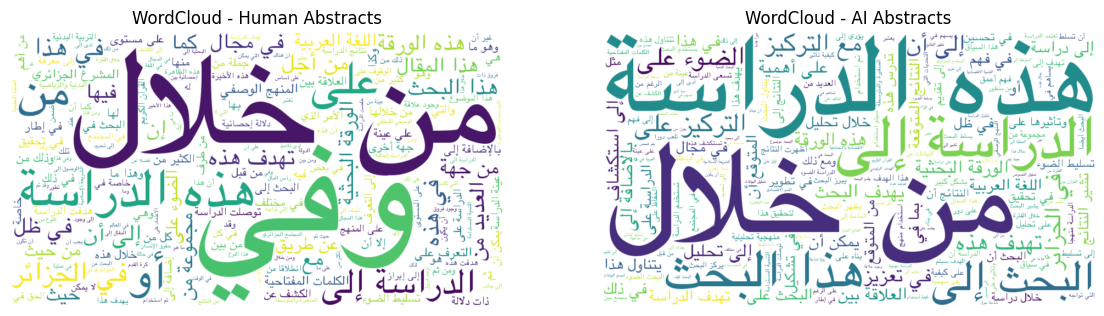

In [39]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

human_raw = " ".join(df[df["label"] == 0]["text"].astype(str).tolist())
ai_raw    = " ".join(df[df["label"] == 1]["text"].astype(str).tolist())

human_text = prepare_arabic(human_raw)
ai_text    = prepare_arabic(ai_raw)

arabic_font = "/System/Library/Fonts/GeezaPro.ttc"

wc_human = WordCloud(
    width=900,
    height=500,
    font_path=arabic_font,
    background_color="white"
).generate(human_text)

wc_ai = WordCloud(
    width=900,
    height=500,
    font_path=arabic_font,
    background_color="white"
).generate(ai_text)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(wc_human, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud - Human Abstracts")

plt.subplot(1, 2, 2)
plt.imshow(wc_ai, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud - AI Abstracts")

plt.show()

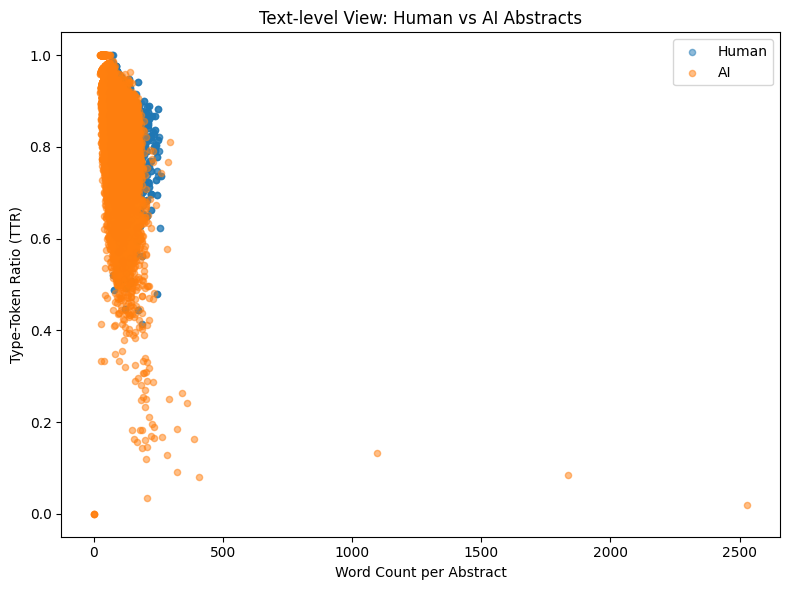

In [42]:
import numpy as np
import matplotlib.pyplot as plt

def compute_ttr(text: str) -> float:
    tokens = str(text).split()
    if len(tokens) == 0:
        return 0.0
    return len(set(tokens)) / len(tokens)

df["word_count"] = df["clean_text"].str.split().str.len()
df["char_count"] = df["clean_text"].str.len()
df["ttr"] = df["clean_text"].apply(compute_ttr)

human = df[df["label"] == 0]
ai    = df[df["label"] == 1]

plt.figure(figsize=(8, 6))

plt.scatter(
    human["word_count"], human["ttr"],
    alpha=0.5, label="Human", s=20
)
plt.scatter(
    ai["word_count"], ai["ttr"],
    alpha=0.5, label="AI", s=20
)

plt.xlabel("Word Count per Abstract")
plt.ylabel("Type-Token Ratio (TTR)")
plt.title("Text-level View: Human vs AI Abstracts")
plt.legend()
plt.tight_layout()
plt.show()

In [32]:
from sklearn.feature_extraction.text import CountVectorizer

def get_top_ngrams(texts, ngram_range=(1, 1), top_k=20):
    vectorizer = CountVectorizer(ngram_range=ngram_range)
    X = vectorizer.fit_transform(texts)
    freqs = X.sum(axis=0).A1
    vocab = vectorizer.get_feature_names_out()
    freq_pairs = list(zip(vocab, freqs))
    freq_pairs.sort(key=lambda x: x[1], reverse=True)
    return freq_pairs[:top_k]

human_unigrams = get_top_ngrams(df[df["label"] == 0]["clean_text"].astype(str), ngram_range=(1, 1), top_k=20)
ai_unigrams    = get_top_ngrams(df[df["label"] == 1]["clean_text"].astype(str), ngram_range=(1, 1), top_k=20)

print("Top 20 unigrams - Human:")
for w, c in human_unigrams:
    print(f"{w}: {c}")

print("\nTop 20 unigrams - AI:")
for w, c in ai_unigrams:
    print(f"{w}: {c}")

Top 20 unigrams - Human:
علي: 16879
الي: 12830
التي: 9622
ان: 8548
الدراسه: 5601
بين: 4532
او: 4282
الذي: 3958
مع: 2493
البحث: 2350
الجزاير: 2038
كل: 1856
العربيه: 1838
ومن: 1748
الجزايري: 1674
وذلك: 1616
اهم: 1604
بعض: 1569
الا: 1542
تم: 1473

Top 20 unigrams - AI:
علي: 82249
الي: 63172
البحث: 40248
الدراسه: 38378
ان: 29959
بين: 25123
التي: 23081
مع: 22863
مما: 13439
تحليل: 13085
النتايج: 12961
تهدف: 11853
اهميه: 10355
الجزاير: 10218
دراسه: 10166
التركيز: 9618
الضوء: 9417
فهم: 8584
تعزيز: 8387
استخدام: 8283


In [33]:
import re
import pandas as pd

function_words = ["في", "على", "علي", "من", "إلى", "الى", "أن", "إن", "كان", "ليس", "هذا", "هذه", "ذلك", "لكن"]

fw_patterns = {fw: re.compile(rf"(?<!\S){fw}(?!\S)") for fw in function_words}

def count_function_words_regex(text: str):
    text = "" if text is None else str(text)
    counts = {}
    for fw, pattern in fw_patterns.items():
        counts[fw] = len(pattern.findall(text))
    return counts

human_fw = df[df["label"] == 0]["lex_text"].apply(count_function_words_regex)
ai_fw    = df[df["label"] == 1]["lex_text"].apply(count_function_words_regex)

human_fw_mean = pd.DataFrame(list(human_fw)).mean().rename("Human")
ai_fw_mean    = pd.DataFrame(list(ai_fw)).mean().rename("AI")

lex_df = pd.concat([human_fw_mean, ai_fw_mean], axis=1)
lex_df

,Human,AI
في,4.168813,4.425519
على,1.988317,2.440868
علي,0.023963,0.010491
من,3.408918,1.996811
إلى,1.410706,1.882332
الى,0.108369,0.000298
أن,0.834764,0.873003
إن,0.150453,0.018747
كان,0.209227,0.068491
ليس,0.031474,0.015707
